## RQ 7: During the span of the last fifteen years, when did **München** score goals most often in their opponent's city?

In [1]:
import requests
import matplotlib.pyplot as plt

In [2]:
# get all matches of München during the last 10 years

result = [[], []]
# [0] year, [1] number goals away

for x in range(15):
    # get all matches for this season
    season = 2011 + x
    result[0].append(season)
    result[1].append(0)
    url = "https://api.openligadb.de/getmatchdata/bl1/" + str(season)
    response = requests.get(url)
    response = response.json()

    # get all matches, where München played away, total count 17
    for match in response:
        matchIDs = []
        for length in range(len(response)):
            match = response [length]
            if match ['team2'] ['teamId'] == 40:
                matchID = match ['matchID']
                matchIDs.append(matchID)
    
    # get total number of goals away
    for matchID in matchIDs:
        url = "https://api.openligadb.de/getmatchdata/"
        url += str(matchID)
        match = requests.get(url)
        match = match.json()
        goals = match ['goals']
        score1 = 0
        score2 = 0        
        for goal in goals:
            score1new = goal ['scoreTeam1'] 
            score2new = goal ['scoreTeam2']
            if score2new > score2:      # goal away
                result [1] [x] += 1
                score2 = score2new
            else:
                score1 = score1new

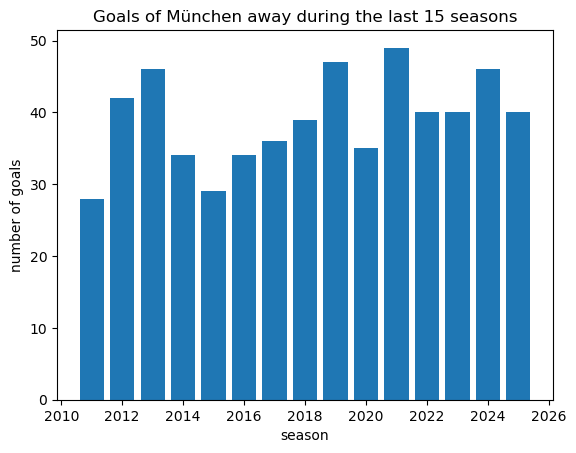

In [8]:
x = result[0]
y = result[1]
plt.bar(x,y)
plt.title('Goals of München away during the last 15 seasons')
plt.xlabel('season')
plt.ylabel('number of goals')
plt.show()